# Assignment 2 — Sanskrit → English Neural Machine Translation



## 1. Installation
All required dependencies (per assignment rules, installation steps are included).

In [8]:
# --- Dependency installation ---
!pip install -q torch sentencepiece nltk bert-score pandas matplotlib

import nltk
nltk.download('punkt', quiet=True)


True

## 2. Get the data into the Colab runtime
Run **ONE** of the two cells below.
* **Option A** — upload the dataset zip directly from your computer (quickest).
* **Option B** — mount Google Drive (recommended: survives runtime disconnects; put the zip in *MyDrive* first).

In [9]:
# --- Option B: load the zip from Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Data_to_Students-20260704T044430Z-3-001.zip'  # adjust if stored elsewhere
!unzip -o -q "/content/Data_to_Students-20260704T044430Z-3-001.zip"
!ls Data_to_Students


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dev_en_1000.csv  test_en_1000.csv  train_en_10000.csv
dev_sa_1000.csv  test_sa_1000.csv  train_sa_10000.csv


## 3. Setup & configuration

In [10]:
import os, time, math, random, unicodedata, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# --- Paths: point DATA_DIR at the unzipped 'Data_to_Students' folder ---
DATA_DIR = 'Data_to_Students'

CFG = dict(
    vocab_size_sa = 4000,      # BPE vocab (source)
    vocab_size_en = 4000,      # BPE vocab (target)
    d_model       = 256,
    nhead         = 4,
    num_layers    = 3,         # encoder layers = decoder layers = 3
    dim_ff        = 1024,
    dropout       = 0.2,
    max_len       = 96,        # max subword length (covers >99% of data)
    batch_size    = 64,
    epochs        = 80,
    lr            = 5e-4,
    warmup_steps  = 1500,
    label_smooth  = 0.1,
    grad_clip     = 1.0,
    beam_size     = 4,
    len_penalty   = 0.6,
    patience      = 10,         # early stopping on dev loss
)


Device: cuda


## 4. Load data

In [11]:
def load_pair(split_sa, split_en):
    sa = pd.read_csv(os.path.join(DATA_DIR, split_sa))
    en = pd.read_csv(os.path.join(DATA_DIR, split_en))
    df = sa.merge(en, on='Source_id')  # align on Source_id
    return df

train_df = load_pair('train_sa_10000.csv', 'train_en_10000.csv')
dev_df   = load_pair('dev_sa_1000.csv',   'dev_en_1000.csv')

# Test: source is required; gold English is available in the released data for self-evaluation.
test_sa  = pd.read_csv(os.path.join(DATA_DIR, 'test_sa_1000.csv'))
TEST_GOLD_PATH = os.path.join(DATA_DIR, 'test_en_1000.csv')
test_gold = pd.read_csv(TEST_GOLD_PATH) if os.path.exists(TEST_GOLD_PATH) else None

print(len(train_df), 'train |', len(dev_df), 'dev |', len(test_sa), 'test')
train_df.head(3)


10000 train | 1000 dev | 1000 test


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


## 5. Preprocessing
Unicode NFC normalization (critical for Devanagari), whitespace cleanup, and removal of wrapping quotes. No lowercasing of Sanskrit; English is kept true-case (BERTScore/BLEU are computed on detokenized output).

In [12]:
def normalize(text):
    text = unicodedata.normalize('NFC', str(text))
    text = text.strip()
    # strip symmetric wrapping quotes
    while len(text) > 1 and text[0] in '"\u201c\u2018\'' and text[-1] in '"\u201d\u2019\'':
        text = text[1:-1].strip()
    text = ' '.join(text.split())
    return text

for df, col in [(train_df,'Sentence_sa'),(train_df,'Sentence_en'),
                (dev_df,'Sentence_sa'),(dev_df,'Sentence_en'),
                (test_sa,'Sentence_sa')]:
    df[col] = df[col].map(normalize)

# drop empty / degenerate training pairs
train_df = train_df[(train_df.Sentence_sa.str.len() > 0) & (train_df.Sentence_en.str.len() > 0)].reset_index(drop=True)
print('train after cleaning:', len(train_df))


train after cleaning: 10000


## 6. Subword tokenization (SentencePiece BPE)
Sanskrit is morphologically rich (33k+ word types in only 10k sentences), so word-level vocabularies suffer severe OOV. We train **separate BPE models** for source and target **on the training split only** (no leakage).

In [13]:
import sentencepiece as spm

os.makedirs('spm', exist_ok=True)
with open('spm/train.sa','w',encoding='utf-8') as f: f.write('\n'.join(train_df.Sentence_sa))
with open('spm/train.en','w',encoding='utf-8') as f: f.write('\n'.join(train_df.Sentence_en))

PAD, UNK, BOS, EOS = 0, 1, 2, 3
common = dict(pad_id=PAD, unk_id=UNK, bos_id=BOS, eos_id=EOS,
              model_type='bpe', character_coverage=1.0)

spm.SentencePieceTrainer.train(input='spm/train.sa', model_prefix='spm/sa',
                               vocab_size=CFG['vocab_size_sa'], **common)
spm.SentencePieceTrainer.train(input='spm/train.en', model_prefix='spm/en',
                               vocab_size=CFG['vocab_size_en'], **common)

sp_sa = spm.SentencePieceProcessor(model_file='spm/sa.model')
sp_en = spm.SentencePieceProcessor(model_file='spm/en.model')
print('vocab sizes:', sp_sa.get_piece_size(), sp_en.get_piece_size())
print(sp_sa.encode(train_df.Sentence_sa[1], out_type=str))


vocab sizes: 4000 4000
['▁ग', 'ुर', 'ुः', '▁छात्र', 'ान्', '▁एक', 'वारं', '▁पाठ', 'यति', '▁।']


## 7. Dataset & DataLoader

In [14]:
MAXLEN = CFG['max_len']

class NMTDataset(Dataset):
    def __init__(self, src_texts, tgt_texts=None):
        self.src = [ [BOS] + sp_sa.encode(s)[:MAXLEN-2] + [EOS] for s in src_texts ]
        self.tgt = None
        if tgt_texts is not None:
            self.tgt = [ [BOS] + sp_en.encode(t)[:MAXLEN-2] + [EOS] for t in tgt_texts ]
    def __len__(self): return len(self.src)
    def __getitem__(self, i):
        return (self.src[i], self.tgt[i] if self.tgt is not None else None)

def collate(batch):
    srcs, tgts = zip(*batch)
    smax = max(len(s) for s in srcs)
    src = torch.full((len(batch), smax), PAD, dtype=torch.long)
    for i,s in enumerate(srcs): src[i,:len(s)] = torch.tensor(s)
    if tgts[0] is None:
        return src, None
    tmax = max(len(t) for t in tgts)
    tgt = torch.full((len(batch), tmax), PAD, dtype=torch.long)
    for i,t in enumerate(tgts): tgt[i,:len(t)] = torch.tensor(t)
    return src, tgt

train_ds = NMTDataset(train_df.Sentence_sa.tolist(), train_df.Sentence_en.tolist())
dev_ds   = NMTDataset(dev_df.Sentence_sa.tolist(),   dev_df.Sentence_en.tolist())

train_dl = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  collate_fn=collate, drop_last=False)
dev_dl   = DataLoader(dev_ds,   batch_size=CFG['batch_size'], shuffle=False, collate_fn=collate)


## 8. Model — custom Transformer encoder–decoder
* Sinusoidal positional encoding
* 3-layer encoder / 3-layer decoder, `d_model=256`, 4 heads, FFN 1024, dropout 0.2
* **Weight tying** between the target embedding and the output projection (reduces parameters, improves the efficiency-parameters score)

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class Seq2SeqTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg['d_model']
        self.d = d
        self.src_emb = nn.Embedding(cfg['vocab_size_sa'], d, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(cfg['vocab_size_en'], d, padding_idx=PAD)
        self.pos = PositionalEncoding(d, max_len=cfg['max_len']+8)
        self.drop = nn.Dropout(cfg['dropout'])
        self.transformer = nn.Transformer(
            d_model=d, nhead=cfg['nhead'],
            num_encoder_layers=cfg['num_layers'], num_decoder_layers=cfg['num_layers'],
            dim_feedforward=cfg['dim_ff'], dropout=cfg['dropout'],
            batch_first=True, norm_first=True)
        self.out = nn.Linear(d, cfg['vocab_size_en'], bias=False)
        self.out.weight = self.tgt_emb.weight   # weight tying

        # --- Init fix: default nn.Embedding std=1.0 explodes the tied output
        # logits (scaled by sqrt(d)), causing epoch-1 loss ~200 and a training
        # collapse. Proper scaled init keeps initial logits well-behaved. ---
        nn.init.normal_(self.src_emb.weight, mean=0.0, std=d ** -0.5)
        nn.init.normal_(self.tgt_emb.weight, mean=0.0, std=d ** -0.5)
        with torch.no_grad():
            self.src_emb.weight[PAD].zero_()
            self.tgt_emb.weight[PAD].zero_()

    def encode(self, src):
        mask = (src == PAD)
        h = self.drop(self.pos(self.src_emb(src) * math.sqrt(self.d)))
        mem = self.transformer.encoder(h, src_key_padding_mask=mask)
        return mem, mask

    def decode(self, tgt_in, mem, mem_pad_mask):
        tpad = (tgt_in == PAD)
        causal = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1), device=tgt_in.device)
        h = self.drop(self.pos(self.tgt_emb(tgt_in) * math.sqrt(self.d)))
        dec = self.transformer.decoder(h, mem, tgt_mask=causal,
                                       tgt_key_padding_mask=tpad,
                                       memory_key_padding_mask=mem_pad_mask)
        return self.out(dec)

    def forward(self, src, tgt_in):
        mem, mpad = self.encode(src)
        return self.decode(tgt_in, mem, mpad)

model = Seq2SeqTransformer(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params:,}')


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


Total parameters: 7,578,624


## 9. Training
Cross-entropy with label smoothing, Adam with inverse-sqrt warmup schedule, gradient clipping, early stopping on dev loss.

In [16]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=CFG['label_smooth'])
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], betas=(0.9, 0.98), eps=1e-9)

def lr_lambda(step):
    step = max(step, 1)
    w = CFG['warmup_steps']
    return min(step / w, (w / step) ** 0.5)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def run_epoch(dl, train=True):
    model.train(train)
    total, ntok = 0.0, 0
    with torch.set_grad_enabled(train):
        for src, tgt in dl:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                optimizer.step(); scheduler.step()
            tok = (tgt_out != PAD).sum().item()
            total += loss.item() * tok; ntok += tok
    return total / ntok

history = {'train': [], 'dev': []}
best_dev, bad = float('inf'), 0
t0 = time.time()
for ep in range(1, CFG['epochs'] + 1):
    tr = run_epoch(train_dl, True)
    dv = run_epoch(dev_dl, False)
    history['train'].append(tr); history['dev'].append(dv)
    flag = ''
    if dv < best_dev - 1e-4:
        best_dev, bad = dv, 0
        torch.save(model.state_dict(), 'best_model.pt'); flag = ' *saved*'
    else:
        bad += 1
    print(f'epoch {ep:02d}  train {tr:.4f}  dev {dv:.4f}  ({time.time()-t0:.0f}s){flag}')
    if bad >= CFG['patience']:
        print('Early stopping.'); break

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
print('Best dev loss:', round(best_dev, 4))


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch 01  train 8.0172  dev 7.1280  (16s) *saved*
epoch 02  train 6.8523  dev 6.6200  (29s) *saved*
epoch 03  train 6.5428  dev 6.3706  (41s) *saved*
epoch 04  train 6.2805  dev 6.0851  (53s) *saved*
epoch 05  train 6.0057  dev 5.8301  (65s) *saved*
epoch 06  train 5.7518  dev 5.6036  (78s) *saved*
epoch 07  train 5.5262  dev 5.4244  (91s) *saved*
epoch 08  train 5.3297  dev 5.2736  (103s) *saved*
epoch 09  train 5.1506  dev 5.1424  (119s) *saved*
epoch 10  train 4.9765  dev 5.0296  (132s) *saved*
epoch 11  train 4.7992  dev 4.9564  (144s) *saved*
epoch 12  train 4.6428  dev 4.8743  (157s) *saved*
epoch 13  train 4.5033  dev 4.8045  (171s) *saved*
epoch 14  train 4.3761  dev 4.7662  (184s) *saved*
epoch 15  train 4.2654  dev 4.7253  (197s) *saved*
epoch 16  train 4.1665  dev 4.7063  (210s) *saved*
epoch 17  train 4.0740  dev 4.6813  (222s) *saved*
epoch 18  train 3.9933  dev 4.6581  (235s) *saved*
epoch 19  train 3.9129  dev 4.6606  (247s)
epoch 20  train 3.8415  dev 4.6464  (260s) *sa

### Training curves (saved for the report)

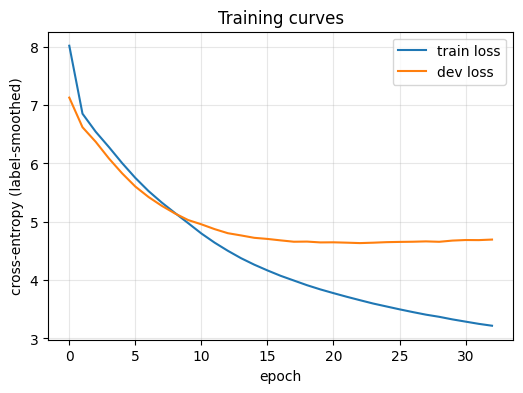

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history['train'], label='train loss')
plt.plot(history['dev'], label='dev loss')
plt.xlabel('epoch'); plt.ylabel('cross-entropy (label-smoothed)')
plt.legend(); plt.title('Training curves'); plt.grid(alpha=.3)
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Back up the trained model to Google Drive (only if you used Option B)
So the checkpoint survives a Colab disconnect and can be reused for the in-class private-test evaluation without retraining.

In [18]:
import os
if os.path.exists('/content/drive/MyDrive'):
    !cp best_model.pt spm/sa.model spm/en.model /content/drive/MyDrive/
    print('Checkpoint + tokenizers backed up to Drive.')
else:
    print('Drive not mounted — skipping backup (fine if you used Option A).')


Checkpoint + tokenizers backed up to Drive.


## 10. Decoding — batched greedy + beam search

In [19]:
@torch.no_grad()
def greedy_decode(sentences, max_len=MAXLEN, batch_size=64):
    model.eval()
    out = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        ids = [[BOS] + sp_sa.encode(s)[:MAXLEN-2] + [EOS] for s in batch]
        smax = max(len(x) for x in ids)
        src = torch.full((len(ids), smax), PAD, dtype=torch.long)
        for j, x in enumerate(ids): src[j, :len(x)] = torch.tensor(x)
        src = src.to(DEVICE)
        mem, mpad = model.encode(src)
        ys = torch.full((len(ids), 1), BOS, dtype=torch.long, device=DEVICE)
        done = torch.zeros(len(ids), dtype=torch.bool, device=DEVICE)
        for _ in range(max_len - 1):
            logits = model.decode(ys, mem, mpad)[:, -1]
            nxt = logits.argmax(-1, keepdim=True)
            nxt[done] = PAD
            ys = torch.cat([ys, nxt], dim=1)
            done |= (nxt.squeeze(1) == EOS)
            if done.all(): break
        for row in ys.tolist():
            toks = []
            for t in row[1:]:
                if t == EOS: break
                if t not in (PAD, BOS): toks.append(t)
            out.append(sp_en.decode(toks))
    return out

@torch.no_grad()
def beam_decode(sentence, beam=CFG['beam_size'], alpha=CFG['len_penalty'], max_len=MAXLEN):
    model.eval()
    ids = [BOS] + sp_sa.encode(sentence)[:MAXLEN-2] + [EOS]
    src = torch.tensor(ids, device=DEVICE).unsqueeze(0)
    mem, mpad = model.encode(src)
    mem = mem.expand(beam, -1, -1); mpad = mpad.expand(beam, -1)
    ys = torch.full((beam, 1), BOS, dtype=torch.long, device=DEVICE)
    scores = torch.full((beam,), float('-inf'), device=DEVICE); scores[0] = 0.0
    finished = []
    for _ in range(max_len - 1):
        logp = torch.log_softmax(model.decode(ys, mem, mpad)[:, -1], dim=-1)
        cand = scores.unsqueeze(1) + logp                      # (beam, V)
        flat = cand.view(-1)
        top_s, top_i = flat.topk(beam)
        b_idx, tok = top_i // logp.size(-1), top_i % logp.size(-1)
        ys = torch.cat([ys[b_idx], tok.unsqueeze(1)], dim=1)
        scores = top_s
        alive = tok != EOS
        for k in range(beam):
            if not alive[k]:
                lp = ((5 + ys.size(1)) / 6) ** alpha
                finished.append((scores[k].item() / lp, ys[k].tolist()))
                scores[k] = float('-inf')
        if len(finished) >= beam: break
    if not finished:
        finished = [(scores[k].item(), ys[k].tolist()) for k in range(beam)]
    best = max(finished, key=lambda x: x[0])[1]
    toks = [t for t in best[1:] if t not in (PAD, BOS, EOS)]
    if EOS in best[1:]:
        toks = []
        for t in best[1:]:
            if t == EOS: break
            if t not in (PAD, BOS): toks.append(t)
    return sp_en.decode(toks)

def beam_decode_all(sentences, **kw):
    return [beam_decode(s, **kw) for s in sentences]


## 11. Evaluation metrics (as specified)
* **BLEU** — default NLTK `corpus_bleu`, no weights argument passed.
* **BERTScore** — official `bert-score` library, F1 only, `rescale_with_baseline=True`.
* **Efficiency** — total test-set inference time and total parameter count.

In [20]:
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore

def evaluate(preds, golds, label=''):
    refs = [[g.split()] for g in golds]
    hyps = [p.split() for p in preds]
    bleu = corpus_bleu(refs, hyps)          # default NLTK BLEU, no weights
    P, R, F1 = bertscore(preds, golds, lang='en', rescale_with_baseline=True, verbose=False)
    f1 = F1.mean().item()
    print(f'[{label}] BLEU = {bleu:.4f} | BERTScore-F1 (rescaled) = {f1:.4f}')
    return bleu, f1


### Dev-set evaluation: greedy vs beam

In [21]:
dev_src  = dev_df.Sentence_sa.tolist()
dev_gold = dev_df.Sentence_en.tolist()

t = time.perf_counter()
dev_greedy = greedy_decode(dev_src)
print(f'greedy dev inference: {time.perf_counter()-t:.1f}s')
evaluate(dev_greedy, dev_gold, 'dev / greedy')

t = time.perf_counter()
dev_beam = beam_decode_all(dev_src)
print(f'beam-{CFG["beam_size"]} dev inference: {time.perf_counter()-t:.1f}s')
evaluate(dev_beam, dev_gold, f'dev / beam-{CFG["beam_size"]}')


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


greedy dev inference: 11.9s


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

beam-4 dev inference: 108.0s


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[dev / beam-4] BLEU = 0.0729 | BERTScore-F1 (rescaled) = 0.3336


(0.07293800722648748, 0.33363255858421326)

## 12. Test-set inference, efficiency numbers & `submission.csv`
Set `USE_BEAM = True` for best quality (slower) or `False` for fastest inference time. The timed block below is the number reported for the efficiency metric.

In [22]:
USE_BEAM = True   # beam search: higher BLEU; greedy: lower inference time

test_src = test_sa.Sentence_sa.tolist()

t0 = time.perf_counter()
test_pred = beam_decode_all(test_src) if USE_BEAM else greedy_decode(test_src)
inference_time = time.perf_counter() - t0

print(f'=== EFFICIENCY ===')
print(f'Total inference time (test set, {len(test_src)} sentences): {inference_time:.2f} s')
print(f'Total model parameters: {n_params:,}')

submission = pd.DataFrame({'Source_id': test_sa.Source_id, 'Sentence_en': test_pred})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
print('submission.csv written:', submission.shape)
submission.head()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


=== EFFICIENCY ===
Total inference time (test set, 1000 sentences): 104.82 s
Total model parameters: 7,578,624
submission.csv written: (1000, 2)


,Source_id,Sentence_en
0,1,Eclipse.
1,2,"And now I say unto you, That ye shall say unto..."
2,3,"Then, I will click on the 'Ce', I will click o..."
3,4,"As an assignment, we can set the index from 1 ..."
4,5,"And when the second line, I saw the sea in the..."


### Test-set metrics (using released gold references)

In [23]:
if test_gold is not None:
    gold = test_gold.set_index('Source_id').loc[test_sa.Source_id, 'Sentence_en'].map(normalize).tolist()
    evaluate(test_pred, gold, 'test')
else:
    print('No gold test references available — metrics computed on dev only.')


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[test] BLEU = 0.0723 | BERTScore-F1 (rescaled) = 0.3306


## 13. Translation examples (for the report)

In [24]:
idx = random.sample(range(len(dev_src)), 10)
for i in idx:
    print('SA :', dev_src[i])
    print('REF:', dev_gold[i])
    print('PRD:', dev_beam[i])
    print('-' * 80)


SA : अस्तु, इदं सम्यक् दृश्यते ।
REF: Well, it looks better.
PRD: Ok is this.
--------------------------------------------------------------------------------
SA : अधुना पृष्टे अधिकाः एडिट्-विकल्पाः दृश्यन्ते ।
REF: The page now displays more edit options.
PRD: Now, let’s look at the bottom of the page.
--------------------------------------------------------------------------------
SA : बाल: भवत्सु प्रेमं प्रकटयति ।
REF: Boy displays love in you.
PRD: Boy displays affection in you.
--------------------------------------------------------------------------------
SA : वयमधुना assignment रचयितुं जानाम ।
REF: Next we will learn how to create an assignment.
PRD: Now let us learn how to create a class.
--------------------------------------------------------------------------------
SA : किन्तु स तं प्रत्यवदत्, मम का जननी? के वा मम सहजाः?
REF: But he answered and said unto him that told him, Who is my mother? and who are my brethren?
PRD: But he answered and said unto them, What is my Father

## Appendix — Private-test evaluation without retraining
For the in-class evaluation: run Sections 1–3 (installs + data + setup), **skip training**, run the model-definition cell (Section 8) and decoding cell (Section 10), then run the cell below to restore the trained weights and tokenizers, and finally re-run Section 12 with `DATA_DIR`/filenames pointed at the private CSVs.

In [25]:
# Restore trained model + tokenizers from Drive (no retraining needed)
import shutil, os
os.makedirs('spm', exist_ok=True)
for f in ['best_model.pt']:
    if not os.path.exists(f): shutil.copy(f'/content/drive/MyDrive/{f}', f)
for f in ['sa.model','en.model']:
    if not os.path.exists(f'spm/{f}'): shutil.copy(f'/content/drive/MyDrive/{f}', f'spm/{f}')

import sentencepiece as spm
sp_sa = spm.SentencePieceProcessor(model_file='spm/sa.model')
sp_en = spm.SentencePieceProcessor(model_file='spm/en.model')
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()
print('Model and tokenizers restored.')


Model and tokenizers restored.


## 14. Notes / disclosure
* **Architecture is a custom Transformer seq2seq trained from scratch** on the provided dataset only; no pre-trained translation models are used.
* The only pre-trained model involved is **`roberta-large` inside the `bert-score` library**, used purely for the BERTScore *evaluation metric* (as mandated by the assignment), not for translation.
* No external APIs are called anywhere in this notebook.
* Reproducibility: fixed seeds (`SEED=42`); note that minor nondeterminism from CUDA kernels may cause tiny metric variations.

**Evaluating on the private test set:** point `DATA_DIR`/file names at the private CSVs, re-run Sections 4–5 and Section 12 (the trained `best_model.pt` and BPE models are reused; no retraining needed).